<a href="https://colab.research.google.com/github/Sama-Elmogy/Deep-learing-neural-network-ITI-tasks-/blob/main/DAY2_Task2_CNN__modeling_Sama_Ahmed_Elmogy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**0.0_CNN file**

In [32]:
import tensorflow as tf
import numpy as np
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import MaxPooling2D, Conv2D



#**I will use the Fashion-MNIST dataset**  

In [33]:
(train_images, train_labels), (test_images, test_labels) = datasets.fashion_mnist.load_data()

print("Train images:", train_images.shape)
print("Train labels:", train_labels.shape)
print("Test images:", test_images.shape)
print("Test labels:", test_labels.shape)

Train images: (60000, 28, 28)
Train labels: (60000,)
Test images: (10000, 28, 28)
Test labels: (10000,)


In [35]:
#normalize
train_images = train_images.astype("float32") / 255.0
test_images = test_images.astype("float32") / 255.0

print(train_images.shape)
print(test_images.shape)

(60000, 28, 28)
(10000, 28, 28)


In [36]:
# add a channel
train_images = np.expand_dims(train_images, axis=-1)
test_images = np.expand_dims(test_images, axis=-1)

print(train_images.shape)
print(test_images.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [37]:
# resize to 32x32
train_images = tf.image.resize(train_images, [32, 32])
test_images = tf.image.resize(test_images, [32, 32])

print(train_images.shape)
print(test_images.shape)

(60000, 32, 32, 1)
(10000, 32, 32, 1)


In [38]:
#convert greyscale to rgb
input_shape=(32, 32, 3)
train_images = tf.image.grayscale_to_rgb(train_images)
test_images = tf.image.grayscale_to_rgb(test_images)

print(train_images.shape)
print(test_images.shape)

(60000, 32, 32, 3)
(10000, 32, 32, 3)


In [39]:
#labels
train_labels_categorical = to_categorical(train_labels)
test_labels_categorical = to_categorical(test_labels)

print(train_labels_categorical.shape)
print(test_labels_categorical.shape)

(60000, 10)
(10000, 10)


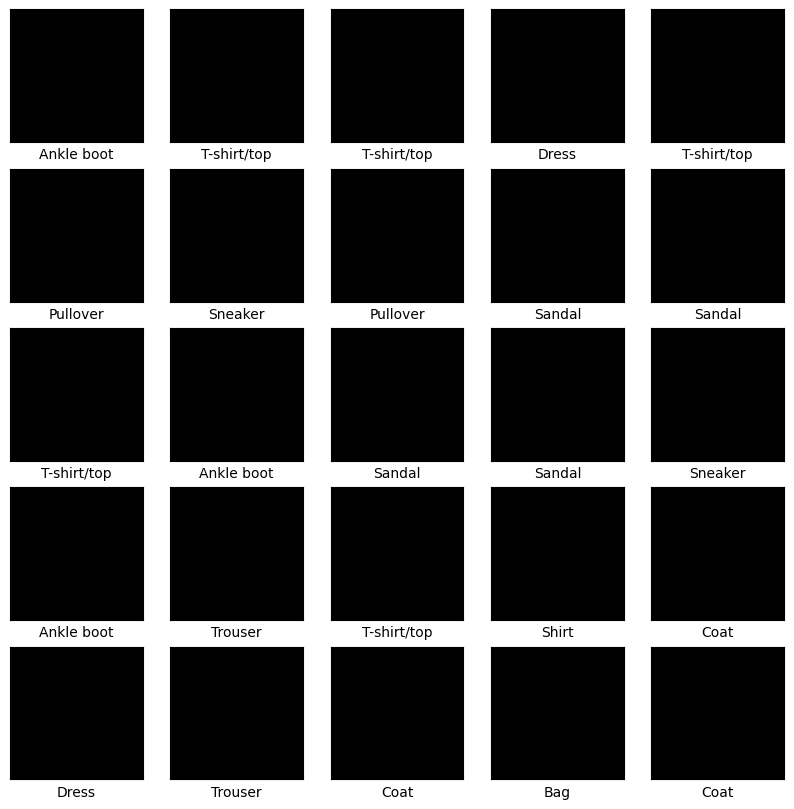

In [40]:
class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

plt.figure(figsize=(10,10))

for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i], cmap='gray')
    plt.xlabel(class_names[train_labels[i]])

plt.show()

In [41]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [42]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,320 (220.00 KB)

 Trainable params: 56,320 (220.00 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10))

In [44]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [45]:
# Assume train_labels is a list or array of class indices (e.g., [0, 1, 2, 0, 1])
train_labels_categorical = to_categorical(train_labels)

In [46]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.CategoricalCrossentropy(),
            #   loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [47]:
history = model.fit(
    train_images,
    train_labels_categorical,
    epochs=10,
    validation_split=0.1,
    batch_size=128
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 37s 83ms/step - accuracy: 0.0990 - loss: 8.0059 - val_accuracy: 0.1055 - val_loss: 8.2310
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 83ms/step - accuracy: 0.0994 - loss: 8.0400 - val_accuracy: 0.1055 - val_loss: 8.2310
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 82ms/step - accuracy: 0.0994 - loss: 8.0400 - val_accuracy: 0.1055 - val_loss: 8.2310
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 35s 83ms/step - accuracy: 0.0994 - loss: 8.0399 - val_accuracy: 0.1055 - val_loss: 8.2310
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 82ms/step - accuracy: 0.0994 - loss: 8.0399 - val_accuracy: 0.1055 - val_loss: 8.2310
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 82ms/step - accuracy: 0.0994 - loss: 8.0399 - val_accuracy: 0.1055 - val_loss: 8.2310
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 81ms/step - accuracy: 0.0994 - loss: 8.0399 - val_accuracy: 0.1055 - val_loss: 8.2310
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 35s 82ms/step - accuracy: 0.0994 - loss: 8.0399 - 

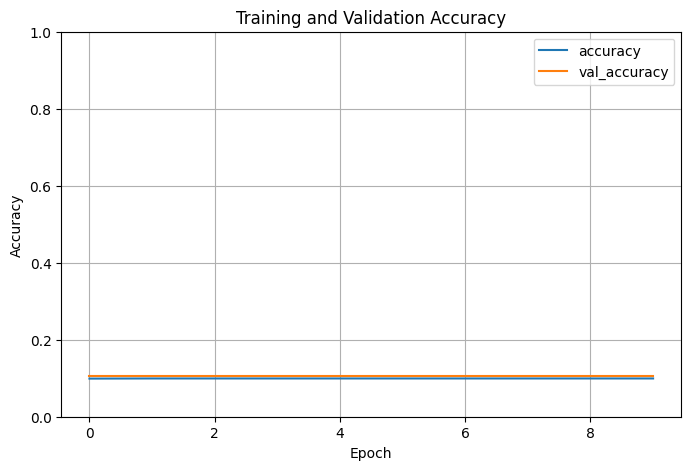

In [54]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')

plt.ylim([0, 1])
plt.legend()
plt.grid(True)

plt.show()

In [50]:
print(test_acc)

0.10000000149011612


#**0.1_Callbacks_CNN**

In [57]:
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import datasets, layers, models
import numpy as np
from tensorflow import keras

In [59]:
(x_train,y_train),(x_test,y_test)=fashion_mnist.load_data()

x_train = x_train.astype('float32')/255

x_test = x_test.astype('float32')/255

In [60]:
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

y_train = to_categorical(y_train,10)
y_test = to_categorical(y_test,10)

print('x_train shape: ',x_train.shape)
print('x_train test: ',x_test.shape)

x_train shape:  (60000, 28, 28, 1)
x_train test:  (10000, 28, 28, 1)


In [62]:
import matplotlib.pyplot as plt


(_, _), (_, labels) = fashion_mnist.load_data()

idx = [3, 6, 25, 46, 58, 85, 93, 99, 108, 133]

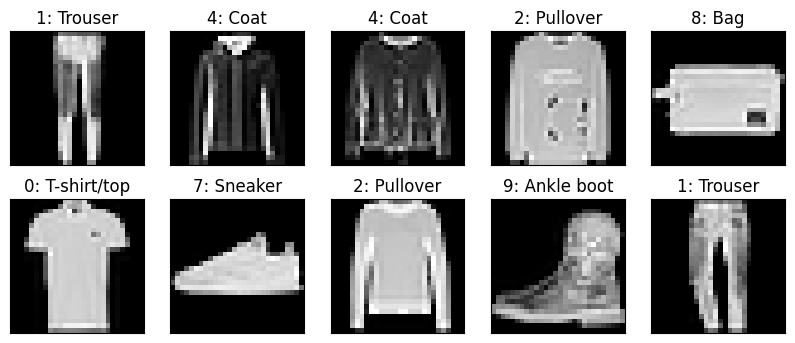

In [63]:
clsmap = {
    0:'T-shirt/top',
    1:'Trouser',
    2:'Pullover',
    3:'Dress',
    4:'Coat',
    5:'Sandal',
    6:'Shirt',
    7:'Sneaker',
    8:'Bag',
    9:'Ankle boot'
}

plt.figure(figsize = (10,4))

for i, (img, y) in enumerate(zip(x_test[idx].reshape(10,28,28), labels[idx])):
  plt.subplot(2,5,i+1)
  plt.imshow(img,cmap='gray')
  plt.xticks([])
  plt.yticks([])
  plt.title(str(y) + ": "+ clsmap[y])

plt.show()

In [64]:
model1 = models.Sequential()

from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import RMSprop

#dimensionality of input and latent encoded representations
inpt_dim = (28,28,1)
inpt_img= Input(shape=inpt_dim)

#Convolutional layer
c11 = Conv2D(64,(9,9), strides=(2,2), input_shape = inpt_dim, activation='relu')(inpt_img)

#Pooling and BatchNorm
p12 = MaxPooling2D(pool_size = (2,2))(c11)
bn13 = BatchNormalization()(p12)

# Add a second convolutional layer
c14 = Conv2D(128,(3,3), strides=(1,1), activation='relu')(bn13)
p15 = MaxPooling2D(pool_size = (2,2))(c14)
bn16 = BatchNormalization()(p15)

# Flattening for compatibility
f17 = Flatten()(bn16)

#Dense layers+ Dropout
do18 = Dropout(0.5)(f17)
d19 = Dense(units = 256,activation = 'relu')(do18)
do110 = Dropout(0.2)(d19)
d111 = Dense(units = 64, activation = 'relu')(do110)
do112 = Dropout(0.1)(d111)
output= Dense(units = 10, activation='sigmoid')(do112)

classifier = Model(inpt_img, output)
opt = RMSprop(learning_rate=0.001)
classifier.compile(optimizer=opt, loss='binary_crossentropy',metrics=['accuracy'])
print(classifier.summary())

Model: "functional_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 10, 10, 64)     │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 5, 5, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1, 1, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 129,994 (507.79 KB)

 Trainable params: 129,610 (506.29 KB)

 Non-trainable params: 384 (1.50 KB)

None


In [65]:
# traing
 # Fitting the CNN to the images
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10,
                              min_delta=1e-4, mode='min', verbose=1)

stop_alg = EarlyStopping(monitor='val_loss', patience=35,
                         restore_best_weights=True, verbose=1)

checkpoint_filepath = 'cnn_model.h5'

model_checkpoint = ModelCheckpoint(
    filepath=checkpoint_filepath,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True)

hist = classifier.fit(x_train, y_train, batch_size=512, epochs=10,
                   callbacks=[stop_alg, reduce_lr, model_checkpoint], shuffle=True,
                   validation_data=(x_test, y_test))

classifier.save_weights("cnn1.weights.h5")
classifier.load_weights('cnn1.weights.h5')

Epoch 1/10
117/118 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.5703 - loss: 0.2513

118/118 ━━━━━━━━━━━━━━━━━━━━ 13s 101ms/step - accuracy: 0.6991 - loss: 0.1599 - val_accuracy: 0.2181 - val_loss: 0.3205 - learning_rate: 0.0010
Epoch 2/10
117/118 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.8041 - loss: 0.0985

118/118 ━━━━━━━━━━━━━━━━━━━━ 20s 99ms/step - accuracy: 0.8134 - loss: 0.0940 - val_accuracy: 0.2551 - val_loss: 0.2956 - learning_rate: 0.0010
Epoch 3/10
117/118 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.8328 - loss: 0.0846

118/118 ━━━━━━━━━━━━━━━━━━━━ 20s 98ms/step - accuracy: 0.8360 - loss: 0.0826 - val_accuracy: 0.6171 - val_loss: 0.1785 - learning_rate: 0.0010
Epoch 4/10
117/118 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.8437 - loss: 0.0776

118/118 ━━━━━━━━━━━━━━━━━━━━ 20s 95ms/step - accuracy: 0.8482 - loss: 0.0760 - val_accuracy: 0.6794 - val_loss: 0.1443 - learning_rate: 0.0010
Epoch 5/10
117/118 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.8544 - loss: 0.0728

118/118 ━━━━━━━━━━━━━━━━━━━━ 21s 97ms/step - accuracy: 0.8554 - loss: 0.0718 - val_accuracy: 0.8108 - val_loss: 0.0874 - learning_rate: 0.0010
Epoch 6/10
117/118 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.8580 - loss: 0.0697

118/118 ━━━━━━━━━━━━━━━━━━━━ 21s 98ms/step - accuracy: 0.8623 - loss: 0.0684 - val_accuracy: 0.8464 - val_loss: 0.0736 - learning_rate: 0.0010
Epoch 7/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 20s 98ms/step - accuracy: 0.8675 - loss: 0.0655 - val_accuracy: 0.8166 - val_loss: 0.0893 - learning_rate: 0.0010
Epoch 8/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 11s 96ms/step - accuracy: 0.8725 - loss: 0.0635 - val_accuracy: 0.7988 - val_loss: 0.0911 - learning_rate: 0.0010
Epoch 9/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 21s 98ms/step - accuracy: 0.8782 - loss: 0.0612 - val_accuracy: 0.8325 - val_loss: 0.0809 - learning_rate: 0.0010
Epoch 10/10
117/118 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.8769 - loss: 0.0607

118/118 ━━━━━━━━━━━━━━━━━━━━ 20s 96ms/step - accuracy: 0.8786 - loss: 0.0600 - val_accuracy: 0.8526 - val_loss: 0.0758 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 6.


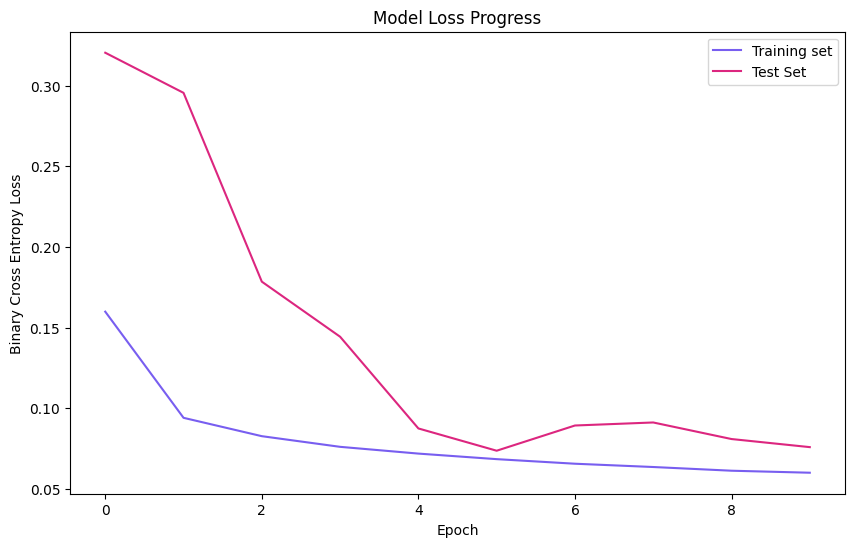

In [66]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10,6))

plt.plot(hist.history['loss'], color='#785ef0')
plt.plot(hist.history['val_loss'], color='#dc267f')

plt.title('Model Loss Progress')
plt.ylabel('Binary Cross Entropy Loss')
plt.xlabel('Epoch')

plt.legend(['Training set','Test Set'], loc='upper right')

plt.show()

In [67]:
from tensorflow.keras.models import load_model

model_loaded = keras.models.load_model('cnn_model.h5')

classifier = model_loaded

classifier.compile(
    optimizer=RMSprop(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [68]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import balanced_accuracy_score
import matplotlib.pyplot as plt
import numpy as np

(_, _),(_, labels) = fashion_mnist.load_data()

y_ = labels

y_hat = classifier.predict(x_test)
y_pred = np.argmax(y_hat, axis=1)

print(classification_report(
    np.argmax(y_test,axis=1),
    np.argmax(y_hat, axis=1),
    labels=[0,1,2,3,4,5,6,7,8,9],
    target_names=[
        'T-shirt/top',
        'Trouser',
        'Pullover',
        'Dress',
        'Coat',
        'Sandal',
        'Shirt',
        'Sneaker',
        'Bag',
        'Ankle boot'
    ]
))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
              precision    recall  f1-score   support

 T-shirt/top       0.68      0.92      0.79      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.69      0.89      0.78      1000
       Dress       0.93      0.81      0.87      1000
        Coat       0.73      0.78      0.75      1000
      Sandal       0.97      0.97      0.97      1000
       Shirt       0.79      0.30      0.43      1000
     Sneaker       0.94      0.96      0.95      1000
         Bag       0.92      0.98      0.95      1000
  Ankle boot       0.96      0.95      0.96      1000

    accuracy                           0.85     10000
   macro avg       0.86      0.85      0.84     10000
weighted avg       0.86      0.85      0.84     10000



In [69]:
cm = confusion_matrix(
    np.argmax(y_test, axis=1),
    np.argmax(y_hat, axis=1),
    labels=[0,1,2,3,4,5,6,7,8,9]
)

print(cm)

ber = 1-balanced_accuracy_score(
    np.argmax(y_test, axis=1),
    np.argmax(y_hat, axis=1)
)

print('BER', ber)

[[923   1  35   7   2   1  19   0  12   0]
 [ 13 967   2  12   2   0   0   0   4   0]
 [ 17   0 888   4  59   0  18   0  14   0]
 [ 83   6  45 814  33   0  15   0   3   1]
 [  8   0 150  22 782   0  26   0  12   0]
 [  1   0   0   1   0 966   0  23   0   9]
 [302   1 155  10 195   0 296   0  41   0]
 [  0   0   0   0   0  12   0 964   0  24]
 [  2   0   9   1   3   5   0   2 977   1]
 [  0   0   0   0   0  10   0  41   0 949]]
BER 0.14739999999999998


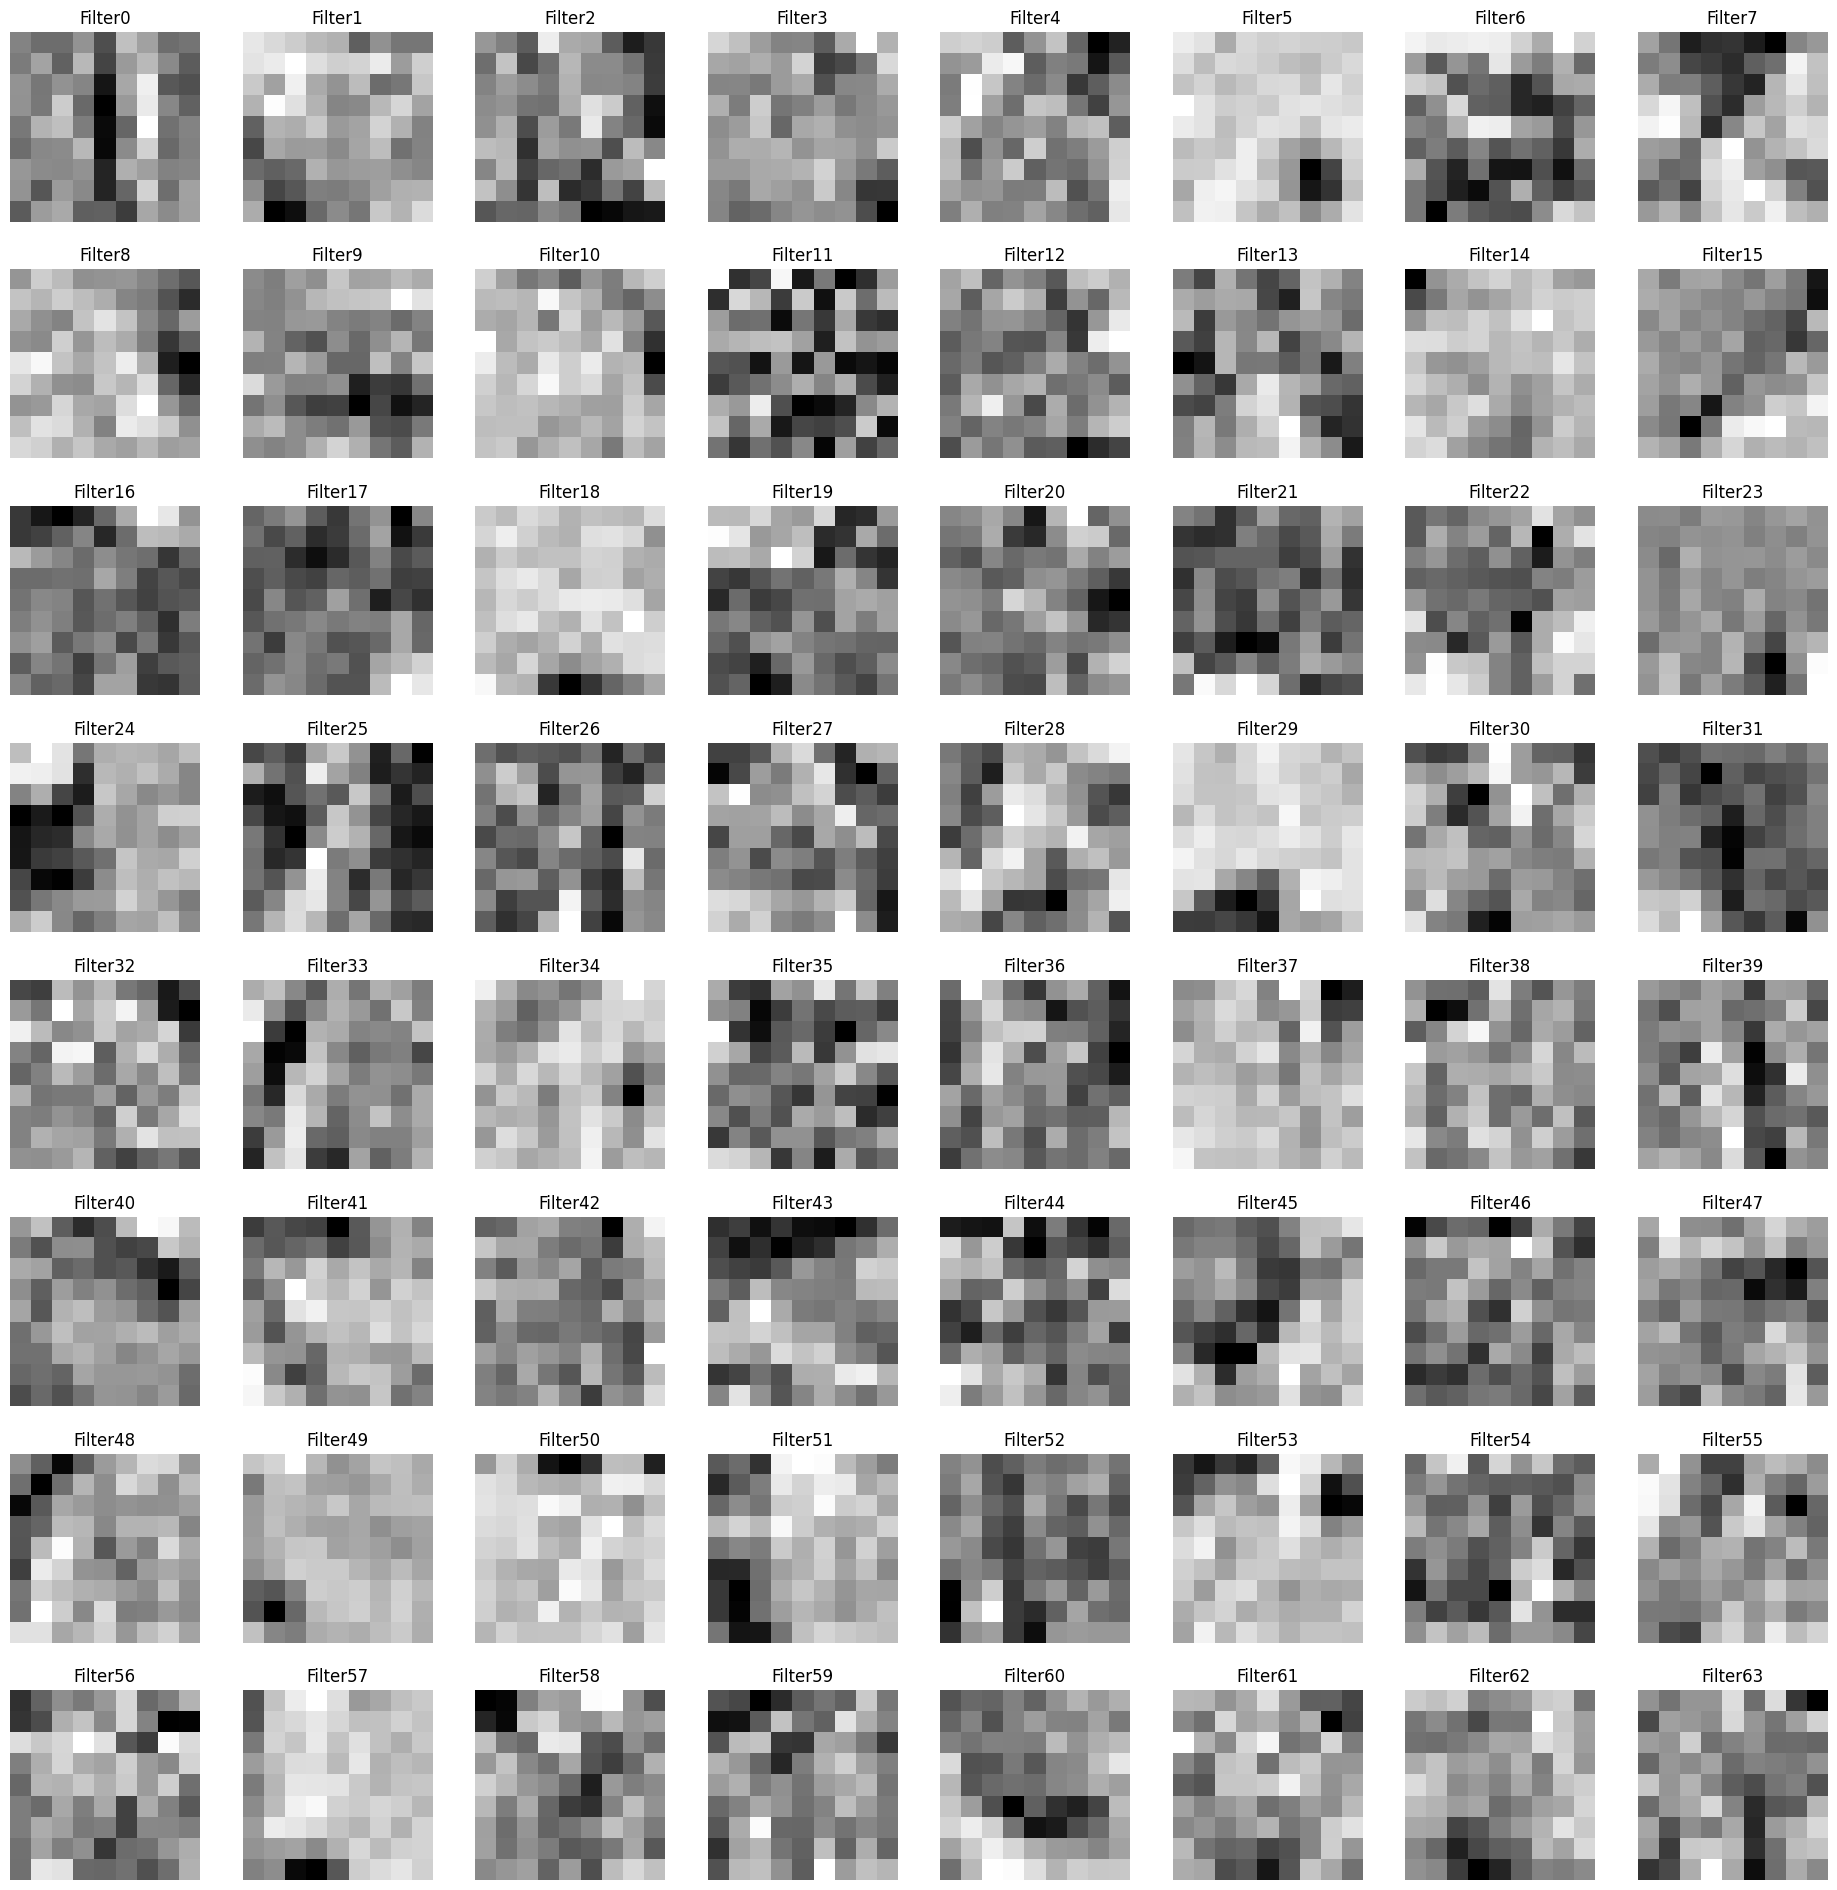

Gabor filters


In [70]:
from sklearn.preprocessing import MinMaxScaler

cnn11 = classifier.layers[1].name # get the name of the 1st convolutional layer

w =classifier.get_layer(name=cnn11).get_weights()[0] # get the filters

wshape = w.shape # save the original shape

# we will scale to [0,1] for visualization purposes
scaler = MinMaxScaler()

scaler.fit(w.reshape(-1,1))

w = scaler.transform(w.reshape(-1,1))

w = w.reshape(wshape)

# we will display them 8x8
fig,axs = plt.subplots(8,8,figsize=(24,24))

fig.subplots_adjust(hspace=.25, wspace=.001)

axs = axs.ravel()

for i in range(w.shape[-1]):
  #we will reshape to a grayscale image shape and display
  h=np.reshape(w[:,:,:,i],(9,9))
  axs[i].imshow(h,cmap='gray')
  axs[i].set_title('Filter'+str(i))
  axs[i].axis('off')

plt.show()

print("Gabor filters")